In [4]:
# !pip install scanpy
# !pip install spatialde

In [ ]:
# %pip uninstall -y SpatialDE
# %pip install -U spatialde-modern

In [ ]:
# import SpatialDE
# print("SpatialDE imported successfully")

In [ ]:
# import SpatialDE
# print("SpatialDE imported successfully")

In [5]:
import scanpy as sc

In [6]:
adata = sc.datasets.visium_sge(sample_id='Parent_Visium_Human_Glioblastoma')

C:\Users\User\AppData\Local\Temp\ipykernel_16056\2118976893.py:1: FutureWarning: The function visium_sge is deprecated and will be removed in the future. Use :func:`squidpy.datasets.visium` instead.
  adata = sc.datasets.visium_sge(sample_id='Parent_Visium_Human_Glioblastoma')
C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scanpy\readwrite.py:248: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata = adata.copy()


In [7]:
adata

AnnData object with n_obs × n_vars = 3468 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
    layers: None (.X)

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_16056\1673487808.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(adata.obs["total_counts"], kde=False, ax=axs[0])
C:\Users\User\AppData\Local\Temp\ipykernel_16056\1673487808.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(adata.obs["total_counts

<Axes: xlabel='n_genes_by_counts'>

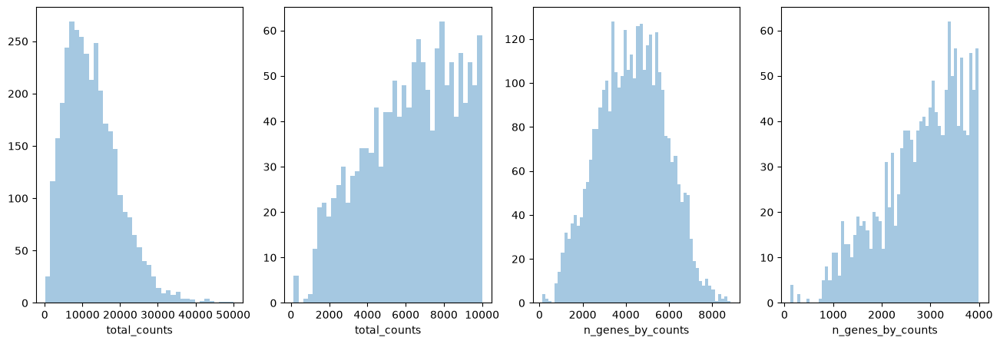

In [10]:
fig, axs = plt.subplots(1, 4, figsize=(16, 5))
sns.distplot(adata.obs["total_counts"], kde=False, ax=axs[0])
sns.distplot(adata.obs["total_counts"][adata.obs["total_counts"] < 10000], kde=False, bins=40, ax=axs[1])
sns.distplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
sns.distplot(adata.obs["n_genes_by_counts"][adata.obs["n_genes_by_counts"] < 4000], kde=False, bins=60, ax=axs[3])

In [11]:
sc.pp.filter_cells(adata, min_counts=2000)
sc.pp.filter_cells(adata, max_counts=20000)
adata = adata[adata.obs["pct_counts_mt"] < 20]
print(f"#cells after MT filter: {adata.n_obs}")
sc.pp.filter_genes(adata, min_cells=10)

C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scanpy\preprocessing\_simple.py:164: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata._inplace_subset_obs(cell_subset)
C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scanpy\preprocessing\_simple.py:164: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata._inplace_subset_obs(cell_subset)
C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scanpy\preprocessing\_simple.py:164: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata._inplace_subset_obs(cell_subset)
C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scanpy\preprocessing\_simple.py:164: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata._inplace_subset_obs(cell_subset)


#cells after MT filter: 2870


C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scanpy\preprocessing\_simple.py:280: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number
C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:141: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  return next(self.gen)
C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  next(self.gen)
C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scanpy\preprocessing\_simple.py:281: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  adata._inplace_subset_var(gene_subset)
C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scanpy\preprocessing\_simple.py:281: UserWarning: Var

In [12]:
adata

AnnData object with n_obs × n_vars = 2870 × 18618
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'
    layers: None (.X)

In [13]:
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=200)

In [14]:
!pip install leidenalg

In [15]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, key_added="clusters")

C:\Users\User\AppData\Local\Temp\ipykernel_16056\3238866047.py:4: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_added="clusters")


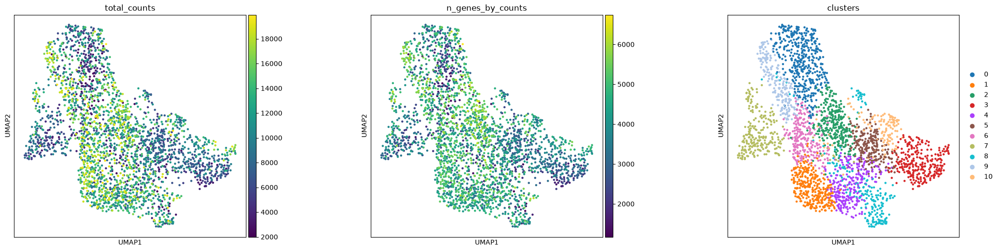

In [16]:
plt.rcParams["figure.figsize"] = (6, 6)
sc.pl.umap(adata, color=["total_counts", "n_genes_by_counts", "clusters"], wspace=0.4)

C:\Users\User\AppData\Local\Temp\ipykernel_16056\683623648.py:2: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, img_key="hires", color=["total_counts", "n_genes_by_counts"])


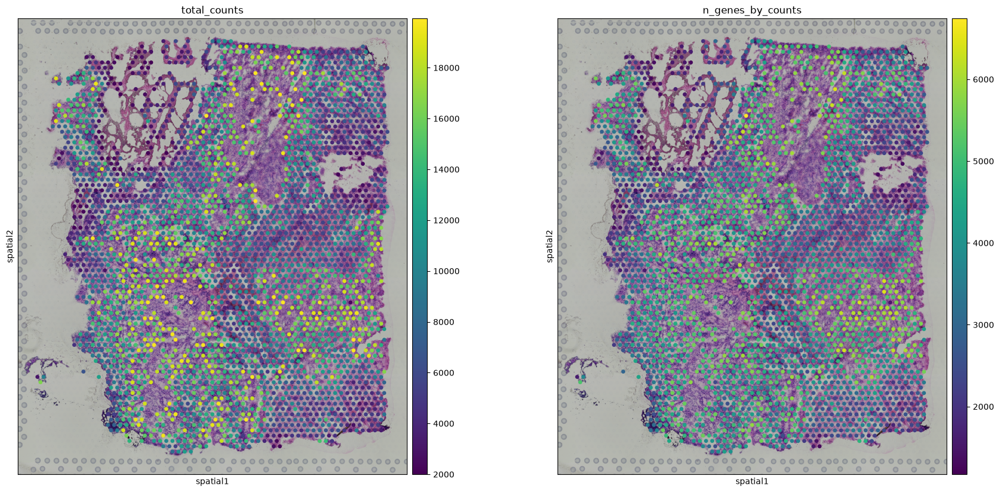

In [17]:
plt.rcParams["figure.figsize"] = (10, 10)
sc.pl.spatial(adata, img_key="hires", color=["total_counts", "n_genes_by_counts"])

C:\Users\User\AppData\Local\Temp\ipykernel_16056\3835171077.py:1: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, img_key="hires", color="clusters", size=1.5, alpha=0.8)


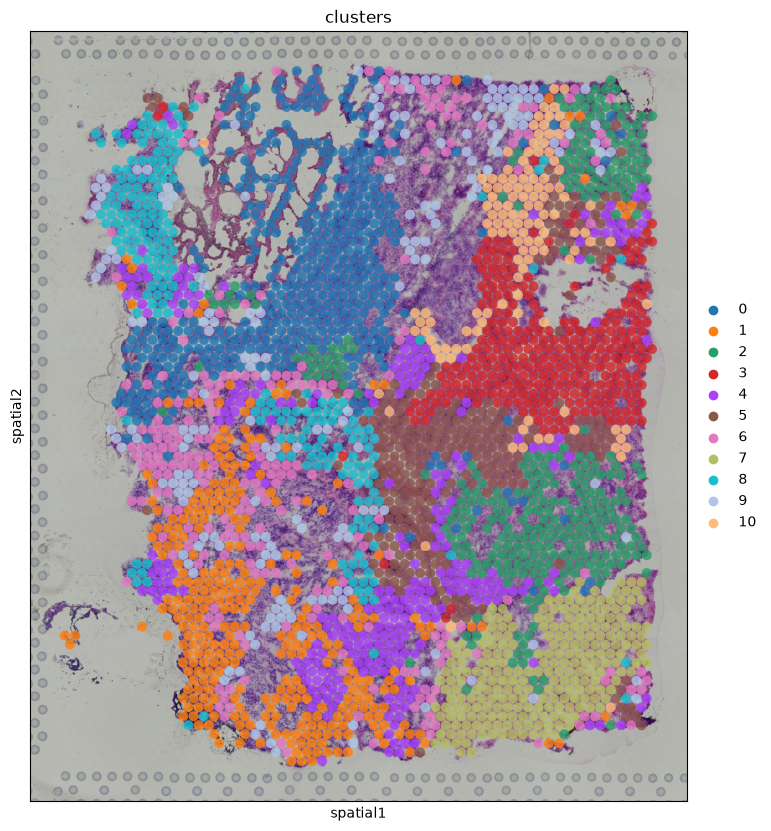

In [18]:
sc.pl.spatial(adata, img_key="hires", color="clusters", size=1.5, alpha=0.8)

C:\Users\User\AppData\Local\Temp\ipykernel_16056\289476551.py:1: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  fig, axes = plt.subplots(1, 3, figsize=(18, 6)); [sc.pl.spatial(adata, img_key="hires", color="clusters",
C:\Users\User\AppData\Local\Temp\ipykernel_16056\289476551.py:1: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  fig, axes = plt.subplots(1, 3, figsize=(18, 6)); [sc.pl.spatial(adata, img_key="hires", color="clusters",
C:\Users\User\AppData\Local\Temp\ipykernel_16056\289476551.py:1: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  fig, axes = plt.subplots(1, 3, figsize=(18, 6)); [sc.pl.spatial(adata, img_key="hires", color="clusters",


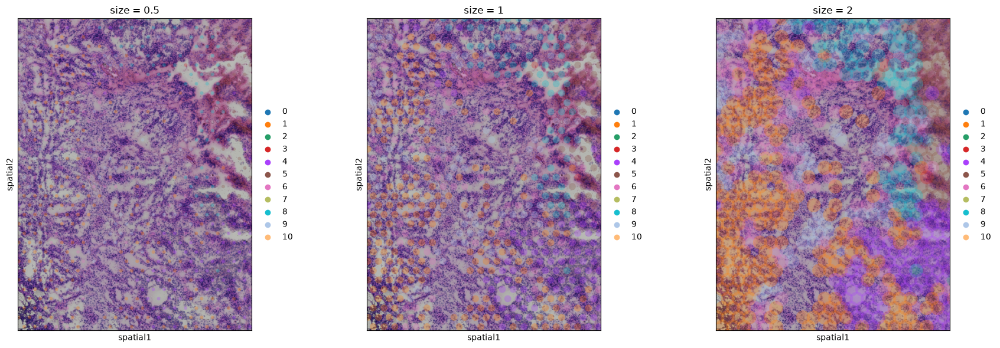

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6)); [sc.pl.spatial(adata, img_key="hires", color="clusters", 
                                                                crop_coord=[4000, 7000, 6000, 10000], alpha=0.3, size=s, ax=ax, show=False, 
                                                                title=f"size = {s}") for ax, s in zip(axes, [0.5, 1, 2])]; plt.tight_layout(); plt.show()

In [20]:
adata.var_names_make_unique() 

categories: 0, 1, 2, etc.
var_group_labels: 1


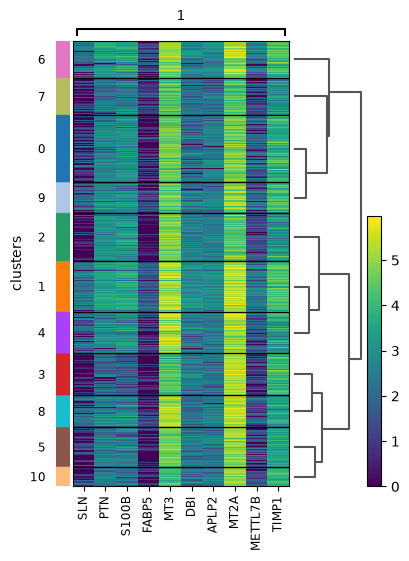

In [21]:
sc.tl.rank_genes_groups(adata, "clusters", method="t-test")
sc.pl.rank_genes_groups_heatmap(adata, groups="1", n_genes=10, groupby="clusters")

C:\Users\User\AppData\Local\Temp\ipykernel_16056\1338016698.py:1: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, img_key="hires", color=["clusters", "EGFR"])


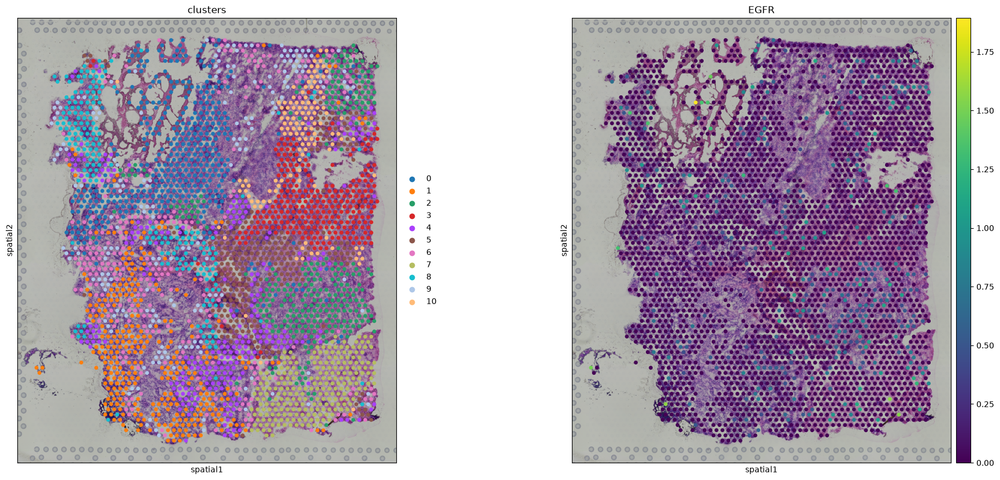

In [22]:
sc.pl.spatial(adata, img_key="hires", color=["clusters", "EGFR"])

In [26]:
# # Why should we experiment all +18K genes?
# counts = pd.DataFrame(adata.X.todense(), columns=adata.var_names, index=adata.obs_names)
# coord = pd.DataFrame(adata.obsm['spatial'], columns=['x_coord', 'y_coord'], index=adata.obs_names)
# results = SpatialDE.run(coord, counts)

In [28]:
## Let's investigate the top 2000 genes and not all of them
# =======================================================================
from tqdm.auto import tqdm
import pandas as pd
import scanpy as sc
import SpatialDE

pbar = tqdm(total=4, desc="SpatialDE Pipeline")

# 1. Select highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000)        ## Let's investigate the top 2000 genes and not all of them
pbar.update(1)

# 2. Keep only HVGs
adata_svg = adata[:, adata.var["highly_variable"]].copy()
pbar.update(1)

# 3. Prepare expression and spatial coordinates
counts = pd.DataFrame(
    adata_svg.X.toarray(),
    columns=adata_svg.var_names,
    index=adata_svg.obs_names
)

coord = pd.DataFrame(
    adata_svg.obsm["spatial"],
    columns=["x_coord", "y_coord"],
    index=adata_svg.obs_names
)

pbar.update(1)

# 4. Run SpatialDE
pbar.set_description("Running SpatialDE")
results = SpatialDE.run(coord, counts)

pbar.update(1)
pbar.set_description("SpatialDE Finished")
pbar.close()

SpatialDE Pipeline:   0%|          | 0/4 [00:00<?, ?it/s]

Models:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

...

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

In [31]:
# results.index = results["g"]
# adata.var = pd.concat([adata.var, results.loc[adata.var.index.values, :]], axis=1)

# Use gene names as index
results = results.set_index("g", drop=False)

# Add SpatialDE results to adata.var
# Non-HVG genes will receive NaN values
adata.var = adata.var.join(
    results.drop(columns="g"),
    how="left"
)

# Show top 10 spatially variable genes
results.sort_values("qval").head(10)

,FSV,M,g,l,max_delta,max_ll,max_mu_hat,max_s2_t_hat,model,n,s2_FSV,s2_logdelta,time,BIC,max_ll_null,LLR,pval,qval
g,,,,,,,,,,,,,,,,,,
NRXN2,0.102374,4,NRXN2,882.408664,8.176018,35.027005,0.068971,0.006784,SE,2870,0.000040,0.004102,0.004416,-38.205741,-111.149000,146.176006,0.0,0.0
CA9,0.182876,4,CA9,882.408664,4.166464,-591.912984,0.127198,0.020367,SE,2870,0.000070,0.003046,0.002194,1215.674237,-876.942946,285.029962,0.0,0.0
IER2,0.118133,4,IER2,465.773703,7.307642,-2076.348480,0.436827,0.035073,SE,2870,0.000019,0.001538,0.003644,4184.545230,-2170.230177,93.881697,0.0,0.0
NRGN,0.466886,4,NRGN,882.408664,1.064742,-753.328078,0.177316,0.086089,SE,2870,0.000106,0.001999,0.001908,1538.504426,-1633.444655,880.116577,0.0,0.0
JUNB,0.322375,4,JUNB,465.773703,2.057665,-2490.607172,0.673951,0.151334,SE,2870,0.000022,0.000500,0.003272,5013.062612,-2919.347975,428.740803,0.0,0.0
ELAVL3,0.125245,4,ELAVL3,465.773703,6.837101,318.962885,0.048401,0.006469,SE,2870,0.000010,0.000729,0.003639,-606.077501,139.774339,179.188545,0.0,0.0
ICAM1,0.131492,4,ICAM1,465.773703,6.465768,-2264.727723,0.488589,0.044964,SE,2870,0.000016,0.001148,0.002935,4561.303715,-2390.607741,125.880018,0.0,0.0
COL5A3,0.218056,4,COL5A3,465.773703,3.510368,-2029.652285,0.405953,0.065425,SE,2870,0.000021,0.000746,0.003436,4091.152840,-2281.316481,251.664195,0.0,0.0
ANGPTL4,0.250419,4,ANGPTL4,465.773703,2.930202,-2150.618181,0.417167,0.083880,SE,2870,0.000032,0.000949,0.002920,4333.084630,-2380.791090,230.172910,0.0,0.0


C:\Users\User\AppData\Local\Temp\ipykernel_16056\3940002749.py:1: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, img_key="hires", color=["SLC9A3R2", "COX20"], alpha=0.8)


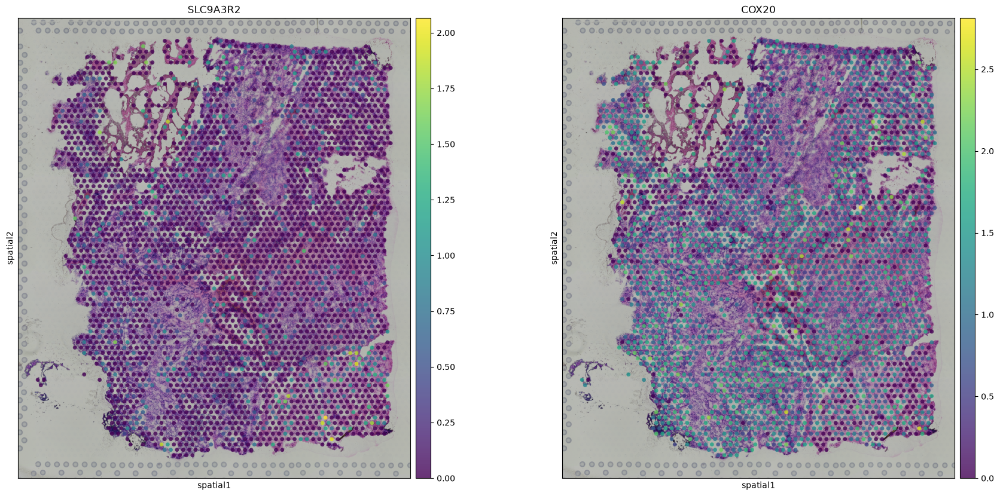

In [33]:
sc.pl.spatial(adata, img_key="hires", color=["SLC9A3R2", "COX20"], alpha=0.8)

#### A previous study developed a supervised machine-learning framework based on Extreme Gradient Boosting (XGBoost) to classify glioblastoma (GBM) into three molecular subtypes: classical, mesenchymal, and proneural.  
#### Through repeated feature-importance analyses, five genes—NKAIN1, UBE2E2, F13A1, RNF149, and PLAUR—were identified as particularly informative for distinguishing among these GBM subtypes. These genes consistently received relatively high importance scores across the XGBoost models.  
#### However, conventional feature-importance measures should be interpreted cautiously because they may not adequately account for dependencies and correlations among predictors. Alternative approaches, such as Null Importance analysis or SHAP-based feature selection methods, including SHAP-Hypetune, may provide a more robust and interpretable assessment of gene relevance.

C:\Users\User\AppData\Local\Temp\ipykernel_16056\4001373691.py:1: FutureWarning: The function spatial is deprecated and will be removed in the future. Use :func:`squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


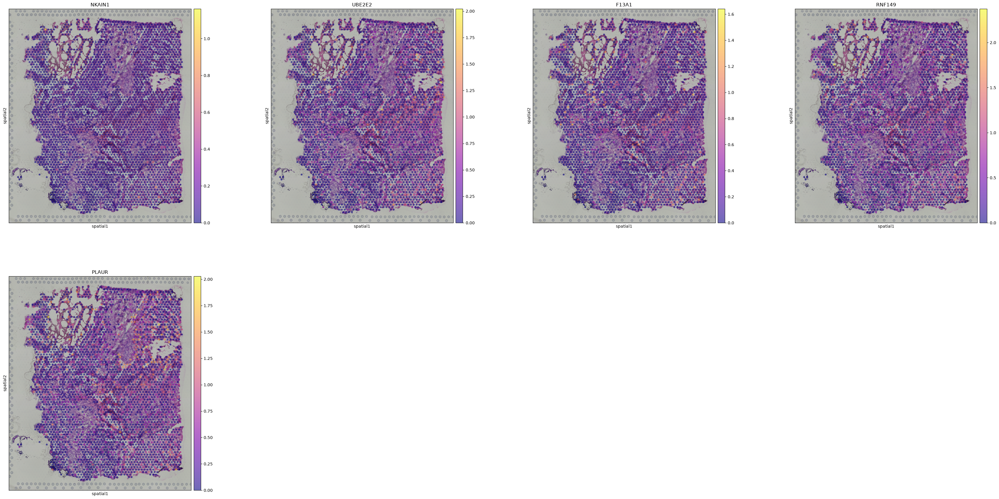

In [36]:
sc.pl.spatial(
    adata,
    img_key="hires",
    color=["NKAIN1", "UBE2E2", "F13A1", "RNF149", "PLAUR"],
    alpha=0.6,
    cmap="plasma"
)

shayanrokhva1999@gmail.com